In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import numpy as np

from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
from pathlib import Path

from sv3.nn import FunctionalModelJac, MLP
from sv3.svd_sgd import SVDOptimizer

import sys
sys.path.append('../..')
import copy

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'legend.fontsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.figsize': (8, 8),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.linewidth': 2,
    'axes.grid': False,
    'grid.alpha': 0.3,
    'font.family': 'arial',
    'legend.frameon': False
})

# Output directory for plots
PLOT_DIR = Path('plots/mnist/')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Plots will be saved to: {PLOT_DIR.absolute()}")

Using device: cuda
Plots will be saved to: /n/home11/sambt/iaifi/sv3/claude_experiments/microbatch_experiments/plots/mnist


In [2]:
from torchvision import datasets, transforms
from experiments.datasets import MNISTDataset

toy_1d = MNISTDataset()
train_dataset = toy_1d.train_dataset
test_dataset = toy_1d.val_dataset

In [6]:
LOADER_SEED = 3871012
batch_size = 64
microbatch_sizes = [1,2,4,8,16,32,64]
K = 32
lr_svd = 0.1
n_epoch = 20
lr_standard = 1e-3
rtol = 1e-3
drop_last = True
mlp_kwargs = {
    "input_dim": 784,
    "hidden_dims": [64,64,64],
    "output_dim": 10
}
standard_optimizers = ['Adam','SGD','RMSprop']

mlp_base = MLP(**mlp_kwargs)
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

### Standard optimizers

In [8]:
losses_standard = {}
for opt_name in standard_optimizers:
    print(f"Running standard training with optimizer: {opt_name}")
    model_standard = MLP(**mlp_kwargs)
    model_standard.load_state_dict(init_state)
    model_standard = model_standard.to(device)

    opt = getattr(torch.optim, opt_name)
    optimizer = opt(model_standard.parameters(), lr=lr_standard)
    loss_fn = nn.CrossEntropyLoss()

    train_loader = DataLoader(toy_1d.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED),drop_last=drop_last)
    test_loader = DataLoader(toy_1d.val_dataset, batch_size=256, shuffle=False)

    model_standard, losses = train_loop_standard(model_standard, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)
    losses_standard[opt_name] = losses

Running standard training with optimizer: Adam
Using device cuda


100%|██████████| 20/20 [01:26<00:00,  4.30s/it]


Running standard training with optimizer: SGD
Using device cuda


100%|██████████| 20/20 [01:25<00:00,  4.26s/it]


Running standard training with optimizer: RMSprop
Using device cuda


100%|██████████| 20/20 [01:26<00:00,  4.33s/it]


### SVD optimizer

In [9]:
svd_info = {}
losses_svd = {}
for microbatch_size in microbatch_sizes:
    print("Running for microbatch size:", microbatch_size)
    model_svd = MLP(**mlp_kwargs)
    model_svd.load_state_dict(init_state)
    model_svd = model_svd.to(device)

    def loss_fn(pred,y):
        loss = nn.CrossEntropyLoss(reduction='none')(pred,y).squeeze()
        return loss

    model_svd = FunctionalModelJac(model_svd, loss_fn, microbatch_size=microbatch_size, device=device)
    optimizer = SVDOptimizer(model_svd,lr=lr_svd,k=K,rtol=rtol,track_svd_info=True)


    train_loader = DataLoader(toy_1d.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED),drop_last=drop_last)
    test_loader = DataLoader(toy_1d.val_dataset, batch_size=256, shuffle=False)

    model_svd, losses_run, optimizer = train_loop_svd(model_svd,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
    svd_info[microbatch_size] = optimizer.svd_info
    losses_svd[microbatch_size] = losses_run

    torch.compiler.reset()

Running for microbatch size: 1


/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/jax/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:236: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
  0%|          | 0/20 [00:00<?, ?it/s]/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1725: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
100%|██████████| 20/20 [03:07<00:00,  9.35s/it]


Running for microbatch size: 2


  0%|          | 0/20 [00:00<?, ?it/s]/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1725: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
100%|██████████| 20/20 [02:33<00:00,  7.67s/it]


Running for microbatch size: 4


...

  0%|          | 0/20 [00:00<?, ?it/s]/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1725: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
100%|██████████| 20/20 [01:16<00:00,  3.84s/it]


Running for microbatch size: 32


  0%|          | 0/20 [00:00<?, ?it/s]/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1725: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
100%|██████████| 20/20 [01:05<00:00,  3.27s/it]


Running for microbatch size: 64


  0%|          | 0/20 [00:00<?, ?it/s]/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1725: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
100%|██████████| 20/20 [00:56<00:00,  2.85s/it]


### Make plots

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

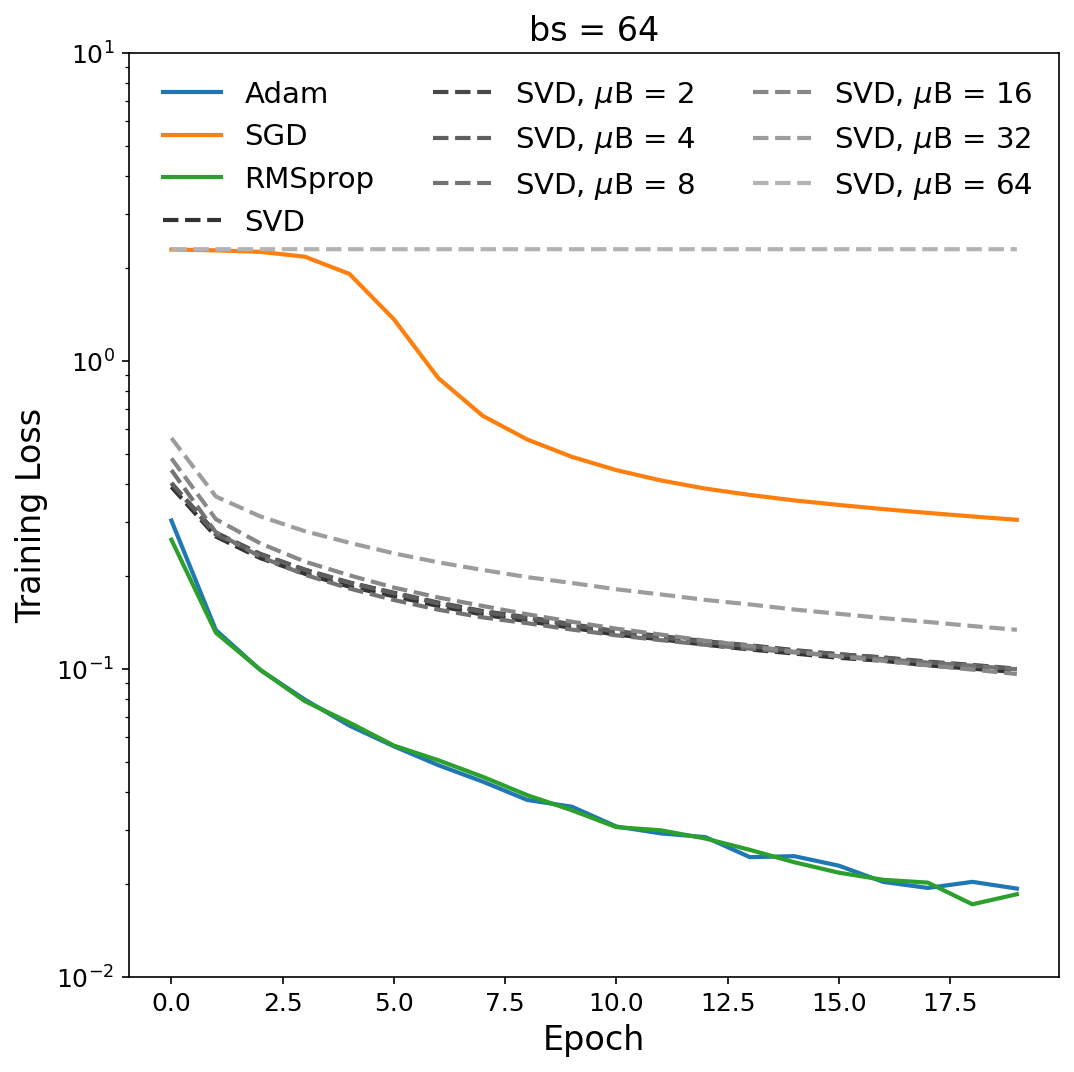

In [13]:
fig, ax = plt.subplots(figsize=(8,8))
for i,opt in enumerate(standard_optimizers):
    ax.plot(np.arange(len(losses_standard[opt]['train'])), losses_standard[opt]['train'], f'C{i}-', label=f'{opt}')
for i, mb in enumerate(microbatch_sizes):
    gray_intensity = 0.2 + (i / (len(microbatch_sizes) - 1)) * 0.5
    label = rf'SVD, $\mu$B = {mb}' if mb > 1 else 'SVD'
    ax.plot(np.arange(len(losses_svd[mb]['train'])), losses_svd[mb]['train'], 
            color=str(gray_intensity), label=label, linestyle='--')
    
ax.set_title(f"bs = {batch_size}")
ax.set_ylabel("Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylim(1e-2, 1e1)
plt.yscale('log')
plt.legend(loc='upper right',ncol=3)
plt.savefig(PLOT_DIR / f"train_loss_mnist_microbatch_comparison_bs{batch_size}_K{K}_lr{lr_svd}_rtol{rtol}.png")

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

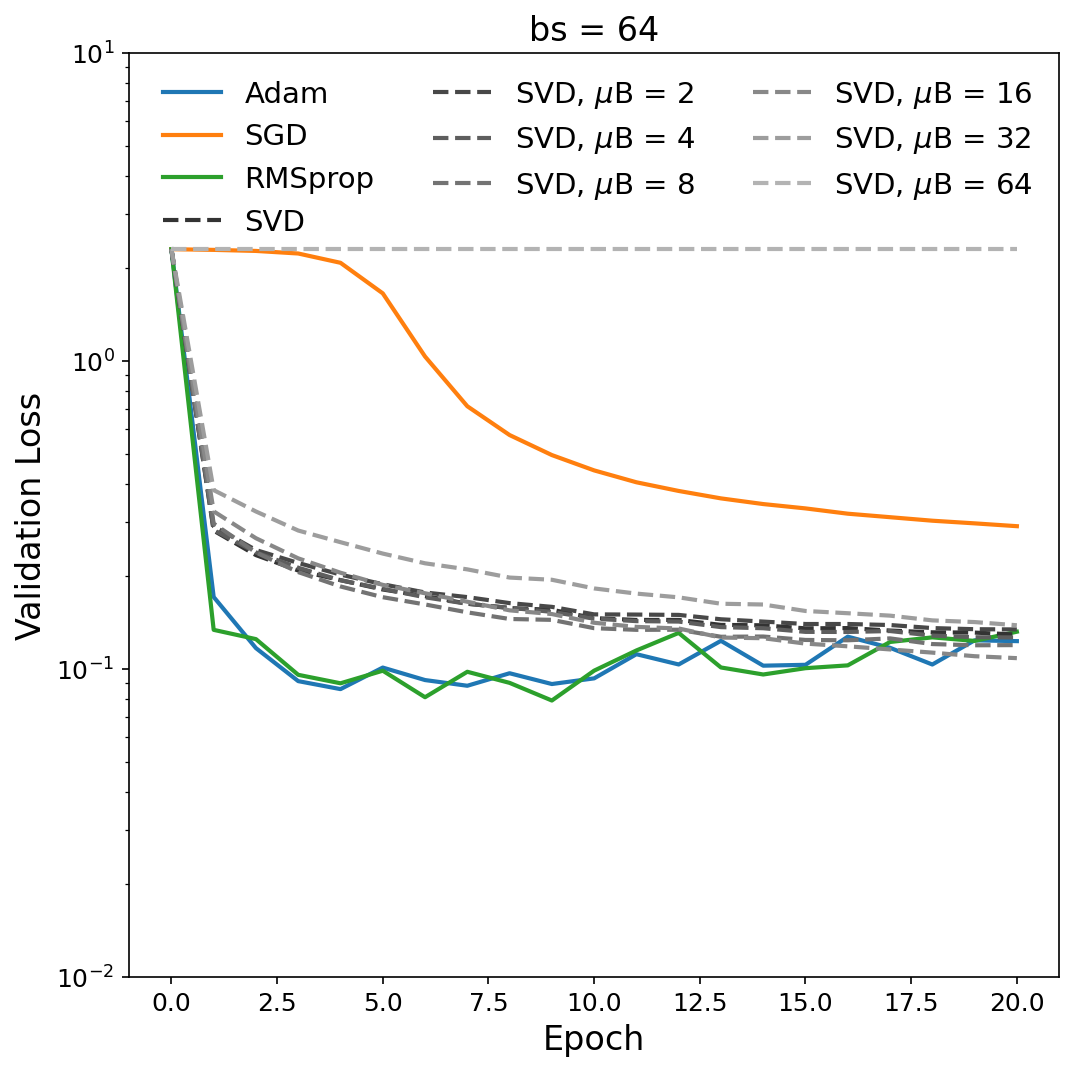

In [14]:
fig, ax = plt.subplots(figsize=(8,8))
for i,opt in enumerate(standard_optimizers):
    ax.plot(np.arange(len(losses_standard[opt]['val'])), losses_standard[opt]['val'], f'C{i}-', label=f'{opt}')
for i, mb in enumerate(microbatch_sizes):
    gray_intensity = 0.2 + (i / (len(microbatch_sizes) - 1)) * 0.5
    label = rf'SVD, $\mu$B = {mb}' if mb > 1 else 'SVD'
    ax.plot(np.arange(len(losses_svd[mb]['val'])), losses_svd[mb]['val'], 
            color=str(gray_intensity), label=label, linestyle='--')
    
ax.set_title(f"bs = {batch_size}")
ax.set_ylabel("Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylim(1e-2, 1e1)
plt.yscale('log')
plt.legend(loc='upper right',ncol=3)
plt.savefig(PLOT_DIR / f"val_loss_mnist_microbatch_comparison_bs{batch_size}_K{K}_lr{lr_svd}_rtol{rtol}.png")